In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('MO','NVDA'), 
         ('MO','AAPL'), 
         ('MO','MSFT'), 
         ('F','NVDA'), 
         ('F', 'AAPL'),
         ('F', 'MSFT'), 
         ('STX','NVDA'), 
         ('STX', 'AAPL'), 
         ('STX','MSFT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

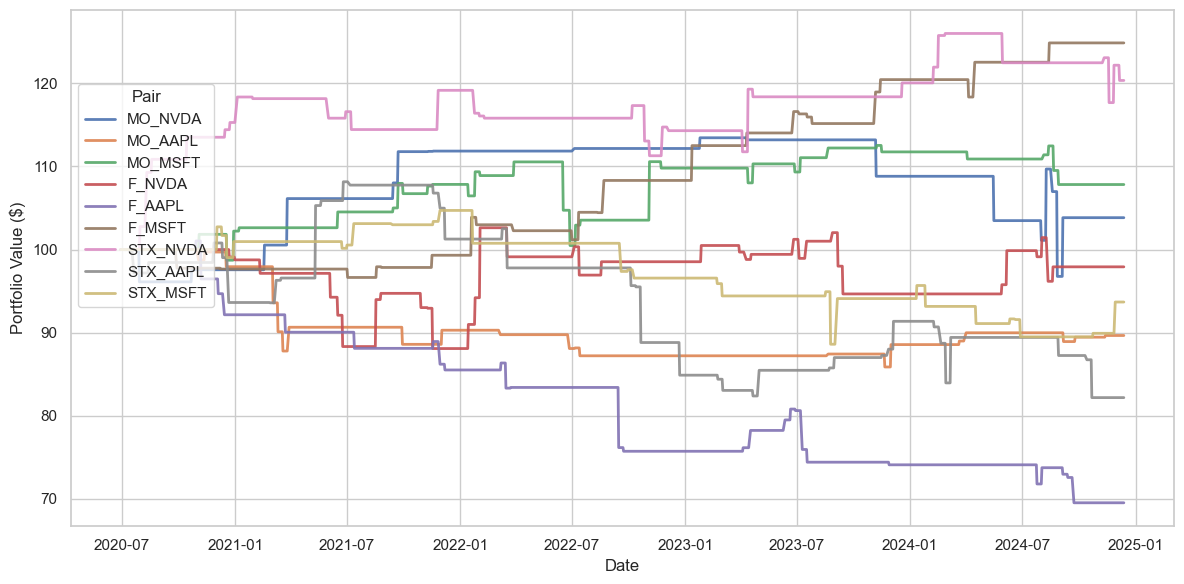

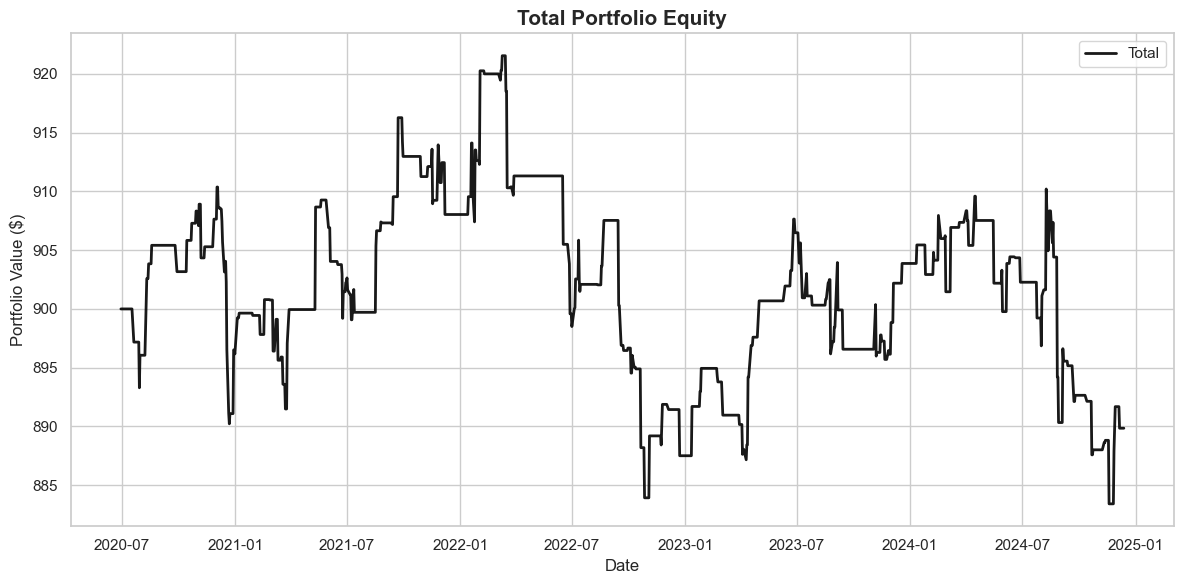

Summary
MO_NVDA: Final Value = $103.84, Total Return = 3.84%, Trades = 18
MO_AAPL: Final Value = $89.65, Total Return = -10.35%, Trades = 22
MO_MSFT: Final Value = $107.83, Total Return = 7.83%, Trades = 32
F_NVDA: Final Value = $97.92, Total Return = -2.08%, Trades = 34
F_AAPL: Final Value = $69.52, Total Return = -30.48%, Trades = 27
F_MSFT: Final Value = $124.88, Total Return = 24.88%, Trades = 24
STX_NVDA: Final Value = $120.36, Total Return = 20.36%, Trades = 32
STX_AAPL: Final Value = $82.18, Total Return = -17.82%, Trades = 37
STX_MSFT: Final Value = $93.68, Total Return = -6.32%, Trades = 27

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $889.85
Total Return:            -1.13%

Sharpe Ratios
MO_NVDA: Sharpe Ratio = 0.14
MO_AAPL: Sharpe Ratio = -0.53
MO_MSFT: Sharpe Ratio = 0.30
F_NVDA: Sharpe Ratio = -0.01
F_AAPL: Sharpe Ratio = -1.10
F_MSFT: Sharpe Ratio = 1.02
STX_NVDA: Sharpe Ratio = 0.61
STX_AAPL: Sharpe Ratio = -0.42
STX_MSFT: Sharpe

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)